## Lecture 4: Functions of Random Variables, Linearity, Variance

**Recap of Lecture 3:** discrete random variables, the PMF, five named distributions
(Bernoulli, Rademacher, Binomial, Geometric, Poisson), and expectation (the Quiz Problem,
the center-of-gravity picture).

**Today:**

- Functions of random variables, revisited: PMF of a transformed RV, and LOTUS
- Linearity of expectation — and why it needs no independence at all
- Moments, and variance

## A linear function of a random variable

Let $C$ be a random variable — today's high temperature in Celsius, say, with some PMF
$p_C$. In Fahrenheit,
$$
F = g(C) = \frac{9}{5}C + 32.
$$
$F$ is a new random variable on the *same* sample space as $C$, defined by
$F(\omega) = g(C(\omega))$.

## The PMF of a transformed RV

If $g$ is **one-to-one** (invertible) on the range of $X$, the PMF of $Y = g(X)$ is easy:
$$
p_Y(y) = P(Y=y) = P(g(X)=y) = P\big(X = g^{-1}(y)\big) = p_X\big(g^{-1}(y)\big).
$$

For Fahrenheit, $g^{-1}(f) = \tfrac59(f-32)$, so $p_F(f) = p_C\!\left(\tfrac59(f-32)\right)$
— the probabilities don't change, only the labels on the axis do.

In [1]:
p_C = {-5: 0.1, 0: 0.2, 10: 0.4, 20: 0.2, 30: 0.1}  # toy PMF for today's high (Celsius)

def celsius_to_f(c):
    return 9 / 5 * c + 32

p_F = {celsius_to_f(c): p for c, p in p_C.items()}

print(f"{'C':>6}{'p_C(C)':>10}   ->   {'F':>8}{'p_F(F)':>10}")
for c in sorted(p_C):
    f = celsius_to_f(c)
    print(f"{c:>6}{p_C[c]:>10.2f}   ->   {f:>8.1f}{p_F[f]:>10.2f}")
print(f"\nsum of p_C = {sum(p_C.values()):.2f},  sum of p_F = {sum(p_F.values()):.2f}")

     C    p_C(C)   ->          F    p_F(F)
    -5      0.10   ->       23.0      0.10
     0      0.20   ->       32.0      0.20
    10      0.40   ->       50.0      0.40
    20      0.20   ->       68.0      0.20
    30      0.10   ->       86.0      0.10

sum of p_C = 1.00,  sum of p_F = 1.00


## LOTUS: the Law Of The Unconscious Statistician

What if we only want $E[Y]$ for $Y = g(X)$, and $g$ *isn't* one-to-one — so finding $p_Y$
takes real work (recall grouping outcomes by value, as we did for the dice-game payout in
Lecture 3)?

::: {.callout-note}
## Theorem: LOTUS
For a discrete RV $X$ and any function $g$,
$$
E[g(X)] = \sum_x g(x)\, p_X(x).
$$
:::

The name is a joke: it feels like computing $E[Y]$ for a random variable $Y=g(X)$ whose
distribution we never bothered to write down!

## LOTUS example 1: the dice-game payout, revisited

Recall $X$ = die roll (uniform on $\{1,\dots,6\}$), and $Y=g(X)$ pays \$2 on even, $-\$1$
on odd. In Lecture 3 we found $p_Y$ first, then computed $E[Y]$. LOTUS skips straight to
the answer:
$$
E[Y] = \sum_{x=1}^{6} g(x)\cdot \frac16.
$$

In [2]:
def g(x):
    return 2 if x % 2 == 0 else -1

E_Y_lotus = sum(g(x) * (1/6) for x in range(1, 7))
print(f"E[Y] via LOTUS (no PMF of Y needed): {E_Y_lotus}")

E[Y] via LOTUS (no PMF of Y needed): 0.5


## LOTUS example 2: randomized Kaczmarz, revisited

Recall from Lecture 3: RK samples a row index $I \in \{1,\dots,m\}$ using the **row-norm
PMF** $p_I(i) = \|a_i\|^2/\|A\|_F^2$. Fix the current iterate $x_k$ and let $v = x_k - x^\star$.
LOTUS lets us compute the expected value of *any* function of $I$ straight from $p_I$ —
for instance
$$
E\!\left[\frac{(a_I^\top v)^2}{\|a_I\|^2}\right] = \sum_{i=1}^m \frac{(a_i^\top v)^2}{\|a_i\|^2}\, p_I(i).
$$

. . .

Plugging in $p_I(i) = \|a_i\|^2/\|A\|_F^2$, the $\|a_i\|^2$ cancels:
$$
\sum_{i=1}^m \frac{(a_i^\top v)^2}{\|a_i\|^2}\cdot\frac{\|a_i\|^2}{\|A\|_F^2}
= \frac{1}{\|A\|_F^2}\sum_{i=1}^m (a_i^\top v)^2 = \frac{\|Av\|^2}{\|A\|_F^2}.
$$

We'll reuse exactly this computation shortly. (If $I$ were sampled **uniformly** instead,
the $\|a_i\|^2$ would *not* cancel, and there'd be no such clean closed form — one reason
the row-norm PMF is RK's standard choice.)

In [3]:
import numpy as np

rng = np.random.default_rng(151)
m, n = 6, 4
A = rng.standard_normal((m, n))
x_star = rng.standard_normal(n)
x_k = rng.standard_normal(n)
v = x_k - x_star

row_norm_sq = (A ** 2).sum(axis=1)
p_row_norm = row_norm_sq / row_norm_sq.sum()
p_uniform = np.full(m, 1 / m)

def h(i):
    return (A[i] @ v) ** 2 / row_norm_sq[i]

lotus_row_norm = sum(h(i) * p_row_norm[i] for i in range(m))
lotus_uniform = sum(h(i) * p_uniform[i] for i in range(m))
closed_form = (A @ v) @ (A @ v) / row_norm_sq.sum()   # ||Av||^2 / ||A||_F^2

print(f"E[h(I)] via LOTUS, row-norm PMF: {lotus_row_norm:.6f}")
print(f"closed form ||Av||^2/||A||_F^2:  {closed_form:.6f}")
print(f"E[h(I)] via LOTUS, uniform PMF:  {lotus_uniform:.6f}  (no clean closed form)")

E[h(I)] via LOTUS, row-norm PMF: 1.512588
closed form ||Av||^2/||A||_F^2:  1.512588
E[h(I)] via LOTUS, uniform PMF:  1.047672  (no clean closed form)


## LOTUS example 3: craps and the sum of two dice

In craps, the shooter rolls two dice; the total $S$ drives the game (7 or 11 on the
come-out roll wins immediately; 2, 3, or 12 lose immediately). Model the roll as a single
RV $X$ — the *pair* $(X_1,X_2)$, uniform over all 36 equally-likely outcomes — and let
$S = g(X) = X_1+X_2$. By LOTUS,
$$
E[S] = \sum_{(x_1,x_2)} (x_1+x_2)\cdot\frac{1}{36}.
$$

In [4]:
from itertools import product
from collections import Counter

outcomes = list(product(range(1, 7), range(1, 7)))
E_S = sum((x1 + x2) * (1/36) for x1, x2 in outcomes)
print(f"E[sum of two dice] via LOTUS = {E_S}")

counts = Counter(x1 + x2 for x1, x2 in outcomes)
print("\nP(S = s) for each total s:")
for s in sorted(counts):
    print(f"  s={s:>2}:  {counts[s]}/36 = {counts[s]/36:.4f}")
print("\n(7 is the single most likely total -- no coincidence it's central to craps rules.)")

E[sum of two dice] via LOTUS = 7.0

P(S = s) for each total s:
  s= 2:  1/36 = 0.0278
  s= 3:  2/36 = 0.0556
  s= 4:  3/36 = 0.0833
  s= 5:  4/36 = 0.1111
  s= 6:  5/36 = 0.1389
  s= 7:  6/36 = 0.1667
  s= 8:  5/36 = 0.1389
  s= 9:  4/36 = 0.1111
  s=10:  3/36 = 0.0833
  s=11:  2/36 = 0.0556
  s=12:  1/36 = 0.0278

(7 is the single most likely total -- no coincidence it's central to craps rules.)


## Linearity of expectation

::: {.callout-note}
## Theorem: Linearity of expectation
For random variables $X,Y$ on the same probability space — **possibly dependent** — and
constants $a,b,c$:
$$
E[aX+bY+c] = aE[X]+bE[Y]+c.
$$
:::

::: {.callout-warning}
## No independence required!
This holds *no matter how $X$ and $Y$ are related*. It's what makes linearity of
expectation so powerful. (Variance will not be so forgiving — stay tuned.)
:::

**Sketch of proof** (writing $p_{X,Y}$ for the joint PMF and $p_X(x)=\sum_y p_{X,Y}(x,y)$
for the marginal — we'll make joint distributions precise soon):
$$
E[X+Y] = \sum_x\sum_y (x+y)\,p_{X,Y}(x,y)
= \sum_x x\sum_y p_{X,Y}(x,y) + \sum_y y\sum_x p_{X,Y}(x,y)
= \sum_x x\,p_X(x) + \sum_y y\,p_Y(y) = E[X]+E[Y].
$$
The constant and scaling terms follow directly from the definition of $E[\cdot]$.

## Linearity also applies to functions of $X$ and $Y$

Combining LOTUS with linearity, for any functions $g,h$:
$$
E[g(X) + h(Y)] = E[g(X)] + E[h(Y)].
$$

We'll use exactly this form below.

In [5]:
import numpy as np

rng = np.random.default_rng(151)
N = 500_000

# Deliberately DEPENDENT: Y is built directly from X
X = rng.integers(1, 7, size=N)
Y = np.where(X <= 3, X, 7 - X)

print(f"E[X] = {X.mean():.4f}, E[Y] = {Y.mean():.4f}")
print(f"E[X] + E[Y] = {X.mean() + Y.mean():.4f}")
print(f"E[X + Y]    = {(X + Y).mean():.4f}   <- matches, even though X, Y are dependent")

E[X] = 3.4998, E[Y] = 1.9987
E[X] + E[Y] = 5.4984
E[X + Y]    = 5.4984   <- matches, even though X, Y are dependent


## The mean of a Binomial, the slick way

Recall from Lecture 3 we derived $E[X]=np$ for $X\sim\text{Binomial}(n,p)$ via a
combinatorial identity. Linearity gives a one-line proof instead.

::: {.callout-note}
## Definition: Indicator random variable
For an event $A$, the indicator $\mathbf 1_A$ equals $1$ if $A$ occurs, $0$ otherwise.
Note $E[\mathbf 1_A] = 1\cdot P(A) + 0\cdot P(A^c) = P(A)$.
:::

::: {.callout-note}
## Definition: i.i.d.
Random variables $X_1,\dots,X_n$ are **independent and identically distributed (i.i.d.)**
if they are mutually independent and all share the same distribution.
:::

Write $X = \sum_{i=1}^n X_i$, where $X_i = \mathbf 1_{\{\text{trial } i \text{ succeeds}\}}$
— i.i.d.\ Bernoulli($p$) indicators. By linearity (independence isn't even needed here!):
$$
E[X] = \sum_{i=1}^n E[X_i] = \sum_{i=1}^n p = np.
$$

In [6]:
import numpy as np

rng = np.random.default_rng(151)
n, p = 10, 0.4
N = 200_000

indicators = rng.random((N, n)) < p     # N experiments, n iid Bernoulli(p) indicators each
X = indicators.sum(axis=1)              # Binomial(n,p) as a sum of indicators

print(f"simulated E[X] = {X.mean():.4f}, theory np = {n*p}")

simulated E[X] = 4.0027, theory np = 4.0


## The coupon collector problem

There are $n$ distinct coupon types; each box contains one coupon, uniformly random among
the $n$ types, independent of previous boxes. Let $T$ = number of boxes needed to collect
all $n$ types. What's $E[T]$?

. . .

Write $T = T_1+T_2+\cdots+T_n$, where $T_i$ = number of *additional* boxes needed to find
a new type, right after collecting the $(i-1)$-th distinct type. With $i-1$ types already
in hand, each new box is a new type with probability $p_i = \frac{n-i+1}{n}$, so
$T_i\sim\text{Geometric}(p_i)$ and $E[T_i] = \frac{n}{n-i+1}$.

. . .

By linearity,
$$
E[T] = \sum_{i=1}^n E[T_i] = \sum_{i=1}^n \frac{n}{n-i+1} = n\sum_{k=1}^n \frac1k = nH_n \approx n\ln n.
$$

In [7]:
import numpy as np

def collect_coupons(n, rng):
    seen = set()
    draws = 0
    while len(seen) < n:
        seen.add(rng.integers(n))
        draws += 1
    return draws

rng = np.random.default_rng(151)
n = 20
trials = 3000
results = [collect_coupons(n, rng) for _ in range(trials)]

H_n = sum(1 / k for k in range(1, n + 1))
print(f"n = {n}")
print(f"simulated average T over {trials} trials: {np.mean(results):.2f}")
print(f"formula n*H_n = {n*H_n:.2f}")

n = 20
simulated average T over 3000 trials: 72.50
formula n*H_n = 71.95


## Linearity + LOTUS: average one-step progress of RK

Recall randomized Kaczmarz's update, and its geometric fact from Lecture 3: with
$v = x_k-x^\star$,
$$
\|x_{k+1}-x^\star\|^2 = \|v\|^2 - \frac{(a_I^\top v)^2}{\|a_I\|^2}.
$$

$\|v\|^2$ is a **constant** given $x_k$ — only $I$ is random. By linearity,
$$
E\big[\|x_{k+1}-x^\star\|^2 \,\big|\, x_k\big]
= \|v\|^2 - E\!\left[\frac{(a_I^\top v)^2}{\|a_I\|^2}\right]
= \|v\|^2 - \frac{\|Av\|^2}{\|A\|_F^2},
$$
reusing the LOTUS computation from a few slides ago!

. . .

Since $\|Av\| \ge \sigma_{\min}(A)\|v\|$,
$$
E\big[\|x_{k+1}-x^\star\|^2 \,\big|\, x_k\big] \;\le\; \left(1 - \frac{\sigma_{\min}(A)^2}{\|A\|_F^2}\right)\|x_k-x^\star\|^2.
$$
Every step shrinks the *expected* squared error by a fixed factor — the classical
randomized-Kaczmarz convergence guarantee (Strohmer–Vershynin).

In [8]:
import numpy as np

rng = np.random.default_rng(151)
m, n = 6, 4
A = rng.standard_normal((m, n))
x_star = rng.standard_normal(n)
x_k = rng.standard_normal(n)
v = x_k - x_star

row_norm_sq = (A ** 2).sum(axis=1)
p_row_norm = row_norm_sq / row_norm_sq.sum()
sigma_min = np.linalg.svd(A, compute_uv=False)[-1]

def one_step_error_sq(i):
    a_i = A[i]
    x_next = x_k - (a_i @ v) / row_norm_sq[i] * a_i
    return np.linalg.norm(x_next - x_star) ** 2

error_by_row = np.array([one_step_error_sq(i) for i in range(m)])

N = 500_000
I_samples = rng.choice(m, size=N, p=p_row_norm)
mc_estimate = error_by_row[I_samples].mean()

closed_form = v @ v - (A @ v) @ (A @ v) / row_norm_sq.sum()
bound = (1 - sigma_min**2 / row_norm_sq.sum()) * (v @ v)

print(f"Monte Carlo E[||x_(k+1)-x*||^2]         = {mc_estimate:.6f}")
print(f"closed form ||v||^2 - ||Av||^2/||A||_F^2 = {closed_form:.6f}")
print(f"||x_k - x*||^2 (before this step)        = {v @ v:.6f}")
print(f"singular-value upper bound                = {bound:.6f}")

Monte Carlo E[||x_(k+1)-x*||^2]         = 2.280903
closed form ||v||^2 - ||Av||^2/||A||_F^2 = 2.280672
||x_k - x*||^2 (before this step)        = 3.793260
singular-value upper bound                = 3.716460


## Watching the bound play out over many steps

The one-step bound says the expected squared error shrinks by a fixed factor *every*
step. Let's actually run RK and watch $\|x_k-x^\star\|^2$ fall, averaged over many
independent random runs.

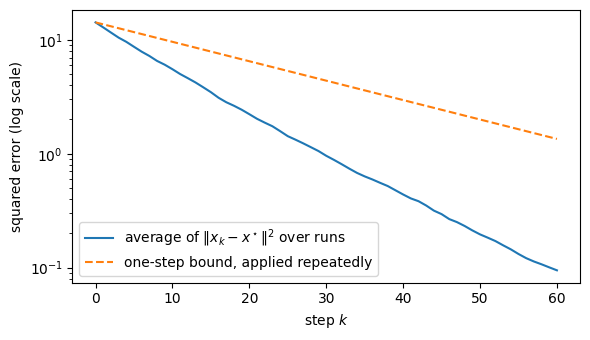

In [9]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(151)
m, n = 20, 8
A = rng.standard_normal((m, n))
x_star = rng.standard_normal(n)
b = A @ x_star
row_norm_sq = (A ** 2).sum(axis=1)
p_row_norm = row_norm_sq / row_norm_sq.sum()
sigma_min = np.linalg.svd(A, compute_uv=False)[-1]
frob_sq = row_norm_sq.sum()

num_steps = 60
num_runs = 300
errors_sq = np.zeros((num_runs, num_steps + 1))

for r in range(num_runs):
    x = np.zeros(n)
    errors_sq[r, 0] = np.linalg.norm(x - x_star) ** 2
    idx_sequence = rng.choice(m, size=num_steps, p=p_row_norm)
    for t, i in enumerate(idx_sequence, start=1):
        a_i, b_i = A[i], b[i]
        x = x + (b_i - a_i @ x) / row_norm_sq[i] * a_i
        errors_sq[r, t] = np.linalg.norm(x - x_star) ** 2

mean_error_sq = errors_sq.mean(axis=0)
bound_curve = errors_sq[:, 0].mean() * (1 - sigma_min**2 / frob_sq) ** np.arange(num_steps + 1)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.semilogy(mean_error_sq, label="average of $\\|x_k-x^\\star\\|^2$ over runs")
ax.semilogy(bound_curve, "--", label="one-step bound, applied repeatedly")
ax.set_xlabel("step $k$")
ax.set_ylabel("squared error (log scale)")
ax.legend()
plt.tight_layout()
plt.show()

## A building block: $E[XY]$ for independent $X,Y$

::: {.callout-note}
## Fact
If $X$ and $Y$ are independent, their joint PMF factors: $p_{X,Y}(x,y)=p_X(x)p_Y(y)$. Then
$$
E[XY] = \sum_x\sum_y xy\,p_{X,Y}(x,y) = \sum_x\sum_y xy\,p_X(x)p_Y(y)
= \Big(\sum_x x\,p_X(x)\Big)\Big(\sum_y y\,p_Y(y)\Big) = E[X]E[Y].
$$
:::

::: {.callout-warning}
## Independence matters here
Unlike $E[X+Y]=E[X]+E[Y]$ (always true, no conditions), $E[XY]=E[X]E[Y]$ generally
*requires* independence — the same asymmetry we'll see again with variance.
:::

## Case study: randomized trace estimation

For a square matrix $A\in\mathbb R^{n\times n}$, the trace $\operatorname{tr}(A)=\sum_i A_{ii}$
is trivial to write down — but for a huge matrix known only *implicitly* (accessible only
through matrix-vector products $Av$), even reading off the diagonal can be expensive.
**Hutchinson's estimator** gets an unbiased estimate from a *single* matrix-vector product.

Let $z=(z_1,\dots,z_n)$ have i.i.d.\ **Rademacher** entries, and set
$$
\tau = z^\top A z = \sum_{i=1}^n\sum_{j=1}^n z_i z_j A_{ij}.
$$

## Unbiasedness: $E[\tau] = \operatorname{tr}(A)$

By linearity of expectation,
$$
E[\tau] = \sum_{i,j} A_{ij}\, E[z_i z_j].
$$

. . .

Split the sum. On the diagonal ($i=j$): $E[z_i^2]=1$, since a Rademacher variable squares
to $1$ *always*. Off the diagonal ($i\ne j$): $z_i \perp z_j$ (independent, by
construction), so by the Fact above $E[z_iz_j]=E[z_i]E[z_j] = 0\cdot 0 = 0$.

. . .

$$
E[\tau] = \sum_i A_{ii}\cdot 1 \;+\; \sum_{i\ne j} A_{ij}\cdot 0 \;=\; \sum_i A_{ii} = \operatorname{tr}(A).
$$

A single random probe $z$ gives, *on average*, exactly the right answer — even though any
one sample $\tau$ can land far from $\operatorname{tr}(A)$. (Sound familiar? We'll measure
exactly how far, with variance, later in the course.)

In [10]:
import numpy as np

rng = np.random.default_rng(151)
n = 50
A = rng.standard_normal((n, n))
true_trace = np.trace(A)

N = 100_000
Z = rng.choice([-1.0, 1.0], size=(N, n))          # N independent Rademacher probe vectors
samples = np.einsum('ij,jk,ik->i', Z, A, Z)        # tau_s = z_s^T A z_s for each sample s

print(f"true trace(A)                    = {true_trace:.4f}")
print(f"mean of {N} Hutchinson samples    = {samples.mean():.4f}")
print(f"a single sample (very noisy!)    = {samples[0]:.4f}")

true trace(A)                    = 0.0783
mean of 100000 Hutchinson samples    = 0.0424
a single sample (very noisy!)    = -10.2049


## Moments

::: {.callout-note}
## Definition: Moments
The $k$-th moment of a random variable $X$ is $E[X^k]$. The mean $E[X]$ is the 1st moment.
The 2nd moment, $E[X^2]$, is about to become useful.
:::

## Why do we need more than the mean?

Suppose you only know $E[\|x_k-x^\star\|^2]$ is small (e.g. from the bound we just
derived). What does that tell you about the error on *any one particular run* of RK?

. . .

**Not much, on its own!** The mean is an average over all randomness; a single run could
still land far from it. To say anything about how *spread out* outcomes are around the
mean, we need a new tool: **variance**.

::: {.callout-tip}
## Aside: the probabilistic method
Expectation alone *can* still be a powerful existence tool: if $E[X]\le c$, then *some*
outcome $\omega$ must satisfy $X(\omega)\le c$ (otherwise every outcome would exceed $c$,
forcing $E[X]>c$). This "probabilistic method" proves existence results in combinatorics
constantly — but it says nothing about *how many* outcomes are near $c$, or how far the
rest can stray. That's what variance is for.
:::

## Variance and standard deviation

::: {.callout-note}
## Definition: Variance
$$
\mathrm{Var}(X) = E\big[(X-E[X])^2\big].
$$
The **standard deviation** is $\sigma_X = \sqrt{\mathrm{Var}(X)}$ — same units as $X$
itself (variance is in squared units), which is often why it's the more interpretable
number.
:::

## Variance of a linear function

For constants $a,b$:
$$
\mathrm{Var}(aX+b) = a^2\,\mathrm{Var}(X).
$$

**Proof:** $E[aX+b] = aE[X]+b$, so
$$
\mathrm{Var}(aX+b) = E\big[(aX+b-aE[X]-b)^2\big] = E\big[a^2(X-E[X])^2\big] = a^2\,\mathrm{Var}(X).
$$
The additive shift $b$ vanishes entirely — variance sees only *spread*, never *location*.

## The variance decomposition (shortcut) formula

::: {.callout-note}
## Theorem
$$
\mathrm{Var}(X) = E[X^2] - \big(E[X]\big)^2.
$$
:::

**Proof:** expand $(X-E[X])^2 = X^2-2XE[X]+(E[X])^2$ and take $E[\cdot]$, using linearity
(note $E[X]$ is a constant):
$$
E\big[(X-E[X])^2\big] = E[X^2]-2E[X]E[X]+(E[X])^2 = E[X^2]-(E[X])^2.
$$
This is almost always the easiest way to *compute* a variance.

## Activity: compute $\mathrm{Var}(X)$ for each named distribution

::: {.callout-caution}
## In-class activity
Using $\mathrm{Var}(X)=E[X^2]-(E[X])^2$, compute $\mathrm{Var}(X)$ for Bernoulli,
Rademacher, Binomial, Geometric, Poisson.
:::

::: {.callout-tip}
## Trick: factorial moments
For a nonnegative-integer-valued $X$, it's often easier to compute
$E[X(X-1)] = E[X^2]-E[X]$ first (the algebra telescopes nicely against factorials in the
PMF), then recover $E[X^2] = E[X(X-1)]+E[X]$.
:::

**Bernoulli($p$):** $X^2=X$ on $\{0,1\}$, so $E[X^2]=E[X]=p$, giving
$\mathrm{Var}(X)=p-p^2=p(1-p)$.

. . .

**Rademacher:** $X^2=1$ always, so $E[X^2]=1$, $E[X]=0$, giving $\mathrm{Var}(X)=1$.

. . .

**Binomial($n,p$):** $E[X(X-1)] = n(n-1)p^2$ (the two "successes" being counted range over
ordered pairs of trials, each pair succeeding with probability $p^2$), so
$E[X^2]=n(n-1)p^2+np$, and
$$
\mathrm{Var}(X) = n(n-1)p^2+np-(np)^2 = np(1-p).
$$

. . .

**Geometric($p$):** conditioning on the first trial (memorylessness: on failure, we're
back to a fresh Geometric($p$) plus one extra trial already spent) gives
$E[X^2]=\dfrac{2-p}{p^2}$, so
$$
\mathrm{Var}(X) = \frac{2-p}{p^2}-\frac1{p^2} = \frac{1-p}{p^2}.
$$

. . .

**Poisson($\lambda$):** $E[X(X-1)]=\lambda^2$ (the sum telescopes against the Poisson
PMF), so $E[X^2]=\lambda^2+\lambda$, giving
$$
\mathrm{Var}(X) = \lambda^2+\lambda-\lambda^2 = \lambda.
$$
(Poisson is the rare distribution with mean $=$ variance!)

In [11]:
import numpy as np

rng = np.random.default_rng(151)
N = 1_000_000

p = 0.3
bernoulli = (rng.random(N) < p).astype(float)
rademacher = rng.choice([-1.0, 1.0], size=N)
n_b, p_b = 10, 0.4
binomial = rng.binomial(n_b, p_b, size=N).astype(float)
p_g = 0.3
geometric = rng.geometric(p_g, size=N).astype(float)
lam = 4
poisson = rng.poisson(lam, size=N).astype(float)

rows = [
    ("Bernoulli(p=0.3)",       bernoulli.var(), p * (1 - p)),
    ("Rademacher",             rademacher.var(), 1.0),
    ("Binomial(n=10,p=0.4)",   binomial.var(),  n_b * p_b * (1 - p_b)),
    ("Geometric(p=0.3)",       geometric.var(), (1 - p_g) / p_g**2),
    ("Poisson(λ=4)",           poisson.var(),   float(lam)),
]

print(f"{'distribution':<22}{'simulated Var(X)':>18}{'theory':>12}")
for name, sim, theory in rows:
    print(f"{name:<22}{sim:>18.4f}{theory:>12.4f}")

distribution            simulated Var(X)      theory
Bernoulli(p=0.3)                  0.2102      0.2100
Rademacher                        1.0000      1.0000
Binomial(n=10,p=0.4)              2.3977      2.4000
Geometric(p=0.3)                  7.7607      7.7778
Poisson(λ=4)                      4.0001      4.0000


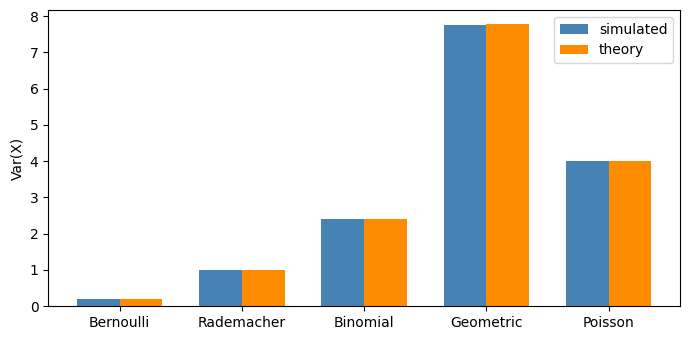

In [12]:
import matplotlib.pyplot as plt
import numpy as np

names = [name.split("(")[0] for name, _, _ in rows]
sims = [sim for _, sim, _ in rows]
theories = [theory for _, _, theory in rows]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(x - width/2, sims, width, label="simulated", color="steelblue")
ax.bar(x + width/2, theories, width, label="theory", color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel("Var(X)")
ax.legend()
plt.tight_layout()
plt.show()

## Variance of a sum — independence *is* required this time

::: {.callout-warning}
## Contrast with linearity of expectation
$E[X+Y]=E[X]+E[Y]$ *always*. But in general
$\mathrm{Var}(X+Y)\ne\mathrm{Var}(X)+\mathrm{Var}(Y)$ — cross terms from how $X$ and $Y$
move together get in the way.
:::

::: {.callout-note}
## Theorem
If $X_1,\dots,X_n$ are **independent**, then
$$
\mathrm{Var}\!\left(\sum_{i=1}^n X_i\right) = \sum_{i=1}^n \mathrm{Var}(X_i).
$$
:::

**Payoff:** writing Binomial($n,p$) as a sum of $n$ i.i.d.\ Bernoulli($p$) indicators
(independent — this time it matters!):
$$
\mathrm{Var}(X) = \sum_{i=1}^n \mathrm{Var}(X_i) = np(1-p),
$$
matching the harder direct computation above — the same slick-proof pattern as the
Binomial mean, earlier in this lecture.

In [13]:
import numpy as np

rng = np.random.default_rng(151)
N = 1_000_000
p, n = 0.4, 10

# Independent case: n iid Bernoulli(p) indicators
indep = rng.random((N, n)) < p
X_indep = indep.sum(axis=1)

# Dependent case: strong positive dependence -- all n coins forced equal
single_flip = rng.random(N) < p
X_dep = np.where(single_flip, n, 0)

print(f"independent sum:  Var(sum) = {X_indep.var():.4f},  sum of Var(X_i) = {n*p*(1-p):.4f}")
print(f"dependent sum:     Var(sum) = {X_dep.var():.4f},  sum of Var(X_i) = {n*p*(1-p):.4f}   <- mismatch!")

independent sum:  Var(sum) = 2.4049,  sum of Var(X_i) = 2.4000
dependent sum:     Var(sum) = 24.0064,  sum of Var(X_i) = 2.4000   <- mismatch!


## Central moments

::: {.callout-note}
## Definition: Central moments
The $k$-th **central moment** of $X$ is $E[(X-E[X])^k]$ — an ordinary moment, but centered
at the mean first.
:::

- The 1st central moment is always $0$ (by definition of the mean).
- The **2nd central moment is exactly the variance** — nothing new, just a name.
- Higher central moments capture other shape features: the 3rd relates to *skewness*
  (asymmetry), the 4th to *kurtosis* (tail heaviness). We won't need these in this course,
  but variance is really just the first member of this whole family.

In [14]:
import numpy as np

rng = np.random.default_rng(151)
n_b, p_b = 10, 0.4
N = 1_000_000
X = rng.binomial(n_b, p_b, size=N).astype(float)
mu = X.mean()

for k in [1, 2, 3]:
    central_moment = np.mean((X - mu) ** k)
    print(f"central moment k={k}: {central_moment:.4f}")

print(f"\nvariance (formula) = {n_b*p_b*(1-p_b):.4f}  <- matches the 2nd central moment")

central moment k=1: -0.0000
central moment k=2: 2.4039
central moment k=3: 0.4905

variance (formula) = 2.4000  <- matches the 2nd central moment


## Looking ahead

- Today: transformed RVs & LOTUS → linearity of expectation (indicators, coupon
  collector, RK, Hutchinson's trace estimator) → variance (definition, decomposition,
  the five distributions, independent sums) → central moments
- Next: joint distributions of several RVs, and the concentration inequalities
  (Markov's, Chebyshev's) that variance was secretly building toward
- Later: how *good* is a single Hutchinson sample? That's a variance question —
  coming back to this estimator once we've built up more tools